# Quantitative Pre-Earnings Signal Detection
**Objective:** To build a robust predictive dataset that anticipates short-term stock price movements leading up to quarterly earnings announcements. 

## 1. Market Data Acquisition & Baseline Setup
The foundation of any quantitative strategy is clean, adjusted price data. In this initial step, we define our target universe of large-cap tech equities (AAPL, MSFT, GOOGL, AMZN, META) and our benchmark (S&P 500). We use `yfinance` to download historical daily OHLCV (Open, High, Low, Close, Volume) data. This raw data will serve as the base for our technical feature engineering.

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np

# --- 1. SETUP & PARAMETERS ---
tickers = [
    # Tech & Semi-conductors (10)
    'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'NVDA', 'AMD', 'TSM', 'AVGO', 'CRM',
    
    # Finance & Payments (10)
    'JPM', 'BAC', 'GS', 'MS', 'V', 'MA', 'WFC', 'C', 'BLK', 'AXP',
    
    # Healthcare & Pharma (8)
    'JNJ', 'UNH', 'LLY', 'PFE', 'MRK', 'ABBV', 'TMO', 'DHR',
    
    # Consumer (Defensive & Cyclical) (8)
    'WMT', 'PG', 'KO', 'PEP', 'COST', 'MCD', 'NKE', 'SBUX',
    
    # Industrials & Energy (8)
    'CAT', 'BA', 'GE', 'UNP', 'CVX', 'XOM', 'COP', 'SLB',
    
    # Telecom, Media & Real Estate (6)
    'DIS', 'NFLX', 'CMCSA', 'VZ', 'AMT', 'PLD'
]  
market_ticker = '^GSPC' # S&P 500 Market Index
start_date = '2014-01-01'
end_date = '2026-01-01'

print("Downloading stock prices and market data...")
all_stocks = []
for ticker in tickers:
    df = yf.download(ticker, start=start_date, end=end_date)
    # Handle multi-index columns for newer versions of yfinance
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.droplevel('Ticker') if 'Ticker' in df.columns.names else [c[0] for c in df.columns]
    df = df.reset_index()
    df.columns = [c.lower() for c in df.columns] 
    df['ticker'] = ticker
    all_stocks.append(df)

stock_data = pd.concat(all_stocks, ignore_index=True)

# Download market data (S&P 500)
market_data = yf.download(market_ticker, start=start_date, end=end_date)
if isinstance(market_data.columns, pd.MultiIndex):
    market_data.columns = [c[0] for c in market_data.columns]
market_data = market_data.reset_index()
market_data.columns = [c.lower() for c in market_data.columns]
market_data = market_data[['date', 'close']].rename(columns={'close': 'sp500_close'})

# Calculate market return
market_data['market_ret'] = market_data['sp500_close'].pct_change()

# Merge stock and market data
panel = stock_data.merge(market_data, on='date', how='left')
panel = panel.sort_values(['ticker', 'date']).reset_index(drop=True)
print("Base data successfully downloaded and merged!")


# --- MACRO & SECTOR DATA DOWNLOAD ---
macro_tickers = {
    '^VIX'  : 'vix',
    '^VIX9D': 'vix9d',
    'HYG'   : 'hyg',
    'IEF'   : 'ief',
}
sector_tickers = {
    'XLK': 'tech', 'XLF': 'finance', 'XLV': 'health',
    'XLP': 'consumer', 'XLI': 'industrial', 'XLC': 'comms',
}
sector_map = {
    'AAPL':'XLK','MSFT':'XLK','GOOGL':'XLK','AMZN':'XLK','META':'XLK',
    'NVDA':'XLK','AMD':'XLK','TSM':'XLK','AVGO':'XLK','CRM':'XLK',
    'JPM':'XLF','BAC':'XLF','GS':'XLF','MS':'XLF','V':'XLF',
    'MA':'XLF','WFC':'XLF','C':'XLF','BLK':'XLF','AXP':'XLF',
    'JNJ':'XLV','UNH':'XLV','LLY':'XLV','PFE':'XLV','MRK':'XLV',
    'ABBV':'XLV','TMO':'XLV','DHR':'XLV',
    'WMT':'XLP','PG':'XLP','KO':'XLP','PEP':'XLP','COST':'XLP',
    'MCD':'XLP','NKE':'XLP','SBUX':'XLP',
    'CAT':'XLI','BA':'XLI','GE':'XLI','UNP':'XLI','CVX':'XLI',
    'XOM':'XLI','COP':'XLI','SLB':'XLI',
    'DIS':'XLC','NFLX':'XLC','CMCSA':'XLC','VZ':'XLC','AMT':'XLC','PLD':'XLC',
}

macro_frames = {}
for yticker, name in {**macro_tickers, **sector_tickers}.items():
    df = yf.download(yticker, start=start_date, end=end_date, progress=False)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [c[0] for c in df.columns]
    df = df.reset_index()
    df.columns = [c.lower() for c in df.columns]
    macro_frames[name] = df[['date', 'close']].rename(columns={'close': name + '_close'})

# Build a single macro dataframe indexed by date
macro_df = macro_frames['vix'].copy()
for name, df in macro_frames.items():
    if name != 'vix':
        macro_df = macro_df.merge(df, on='date', how='outer')
macro_df = macro_df.sort_values('date').reset_index(drop=True)

# Compute macro features
macro_df['vix_level']    = macro_df['vix_close']
macro_df['vix_ts_slope'] = macro_df['vix9d_close'] - macro_df['vix_close']
macro_df['credit_spread']= macro_df['hyg_close'] / (macro_df['ief_close'] + 1e-6)
for col in ['vix_level', 'vix_ts_slope', 'credit_spread']:
    macro_df[col + '_chg5d'] = macro_df[col].diff(5)

# Compute sector daily returns
for name in sector_tickers.values():
    col = name + '_close'
    if col in macro_df.columns:
        macro_df[name + '_ret'] = macro_df[col].pct_change()

print("Macro and sector data downloaded.")

c:\Users\mdist\Documents\Downloads\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\mdist\Documents\Downloads\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


C:\Users\mdist\AppData\Local\Temp\ipykernel_11684\3721550791.py:32: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
C:\Users\mdist\AppData\Local\Temp\ipykernel_11684\3721550791.py:32: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
C:\Users\mdist\AppData\Local\Temp\ipykernel_11684\3721550791.py:32: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
C:\Users\mdist\AppData\Local\Temp\ipykernel_11684\3721550791.py:32: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start

Base data successfully downloaded and merged!


C:\Users\mdist\AppData\Local\Temp\ipykernel_11684\3721550791.py:87: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(yticker, start=start_date, end=end_date, progress=False)
C:\Users\mdist\AppData\Local\Temp\ipykernel_11684\3721550791.py:87: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(yticker, start=start_date, end=end_date, progress=False)
C:\Users\mdist\AppData\Local\Temp\ipykernel_11684\3721550791.py:87: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(yticker, start=start_date, end=end_date, progress=False)
C:\Users\mdist\AppData\Local\Temp\ipykernel_11684\3721550791.py:87: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(yticker, start=start_date, end=end_date, progress=False)
C:\Users\mdist\AppData\Local\Temp\ipykernel_11684\3721550791.py:87: FutureWarning: YF.download() has changed arg

Macro and sector data downloaded.


## 2. Technical Feature Engineering
Raw prices contain too much noise to be fed directly into a machine learning model. To capture the market's behavioral dynamics before an earnings call, we engineer several technical and statistical features:
* **Momentum & Returns:** 7-day and 30-day rolling cumulative returns.
* **Historical Volatility:** 21-day standard deviation of returns.
* **Volume Anomalies:** Daily volume normalized against a 30-day moving average to detect unusual institutional accumulation or distribution.
* **Trend Indicators:** 5-day vs. 30-day Moving Average crossovers.
* **Mean Reversion:** 14-day Relative Strength Index (RSI) and 20-day Bollinger Bands to identify overbought/oversold extremes.
* **Alpha Proxy:** The stock's daily return minus the S&P 500 return, isolating company-specific movement from broader market beta.

In [2]:
# --- 2. FEATURE ENGINEERING ---
print("Calculating quantitative features...")
g = panel.groupby('ticker')

# Price & Volume Features
panel['ret'] = g['close'].pct_change()
panel['ret_7d']  = g['ret'].transform(lambda x: x.rolling(7).sum())
panel['ret_30d'] = g['ret'].transform(lambda x: x.rolling(30).sum())
panel['volatility_21d'] = g['ret'].transform(lambda x: x.rolling(21).std())
panel['vol_avg_30d'] = g['volume'].transform(lambda x: x.rolling(30).mean())
panel['volume_spike'] = panel['volume'] / panel['vol_avg_30d']

# Moving Averages & Alpha
panel['ma5'] = g['close'].transform(lambda x: x.rolling(5).mean())
panel['ma30'] = g['close'].transform(lambda x: x.rolling(30).mean())
panel['ma_cross'] = (panel['ma5'] > panel['ma30']).astype(int)
panel['alpha_proxy'] = panel['ret'] - panel['market_ret']

# RSI (14-day)
def calculate_rsi(series, period=14):
    delta = series.diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    avg_gain = gain.ewm(com=period-1, min_periods=period).mean()
    avg_loss = loss.ewm(com=period-1, min_periods=period).mean()
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

panel['rsi_14'] = g['close'].transform(lambda x: calculate_rsi(x))

# Bollinger Bands (20-day)
panel['bb_mid'] = g['close'].transform(lambda x: x.rolling(20).mean())
panel['bb_std'] = g['close'].transform(lambda x: x.rolling(20).std())
panel['bb_upper'] = panel['bb_mid'] + (panel['bb_std'] * 2)
panel['bb_lower'] = panel['bb_mid'] - (panel['bb_std'] * 2)
panel['bb_position'] = (panel['close'] - panel['bb_lower']) / (panel['bb_upper'] - panel['bb_lower']) 

# --- ADDITIONAL PRICE-BASED FEATURES ---

# 1. Amihud Illiquidity Ratio (Amihud 2002)
panel['dollar_vol'] = panel['close'] * panel['volume']
panel['amihud']     = panel['ret'].abs() / (panel['dollar_vol'] + 1)
panel['amihud_5d']  = g['amihud'].transform(lambda x: x.rolling(5).mean())

# 2. 52-Week High Proximity (George & Hwang 2004)
panel['high_52w']    = g['close'].transform(lambda x: x.rolling(252, min_periods=63).max())
panel['nearness_52w']= panel['close'] / (panel['high_52w'] + 1e-6)

# 3. Garman-Klass Realized Volatility (uses OHLC)
log_hl = (np.log(panel['high'] / (panel['low']  + 1e-6)))**2
log_co = (np.log(panel['close']/ (panel['open'] + 1e-6)))**2
panel['gk_vol']    = np.sqrt(0.5 * log_hl - (2 * np.log(2) - 1) * log_co)
panel['gk_vol_5d'] = g['gk_vol'].transform(lambda x: x.rolling(5).mean())

# 4. MACD Histogram
ema12              = g['close'].transform(lambda x: x.ewm(span=12, adjust=False).mean())
ema26              = g['close'].transform(lambda x: x.ewm(span=26, adjust=False).mean())
panel['macd']      = ema12 - ema26
panel['macd_sig']  = g['macd'].transform(lambda x: x.ewm(span=9, adjust=False).mean())
panel['macd_hist'] = panel['macd'] - panel['macd_sig']

# 5. Idiosyncratic Volatility (Ang et al. 2006)
# Approx: std of daily return unexplained by market
panel['idio_ret']  = panel['ret'] - panel['market_ret']
panel['idio_vol']  = g['idio_ret'].transform(lambda x: x.rolling(21).std())

# 6. Merge macro features onto panel
panel = panel.merge(
    macro_df[['date', 'vix_level', 'vix_ts_slope', 'credit_spread',
            'vix_level_chg5d', 'vix_ts_slope_chg5d', 'credit_spread_chg5d']],
    on='date', how='left'
)

# 7. Sector-relative alpha
panel['sector_etf'] = panel['ticker'].map(sector_map)
sector_ret_df = pd.melt(
    macro_df[['date'] + [s + '_ret' for s in sector_tickers.values()]],
    id_vars='date', var_name='sector_etf', value_name='sector_ret'
)
sector_ret_df['sector_etf'] = sector_ret_df['sector_etf'].str.replace('_ret', '')
sector_ret_df['sector_etf'] = sector_ret_df['sector_etf'].str.upper()
panel['sector_etf_upper'] = panel['sector_etf'].str.upper()
panel = panel.merge(sector_ret_df, left_on=['date','sector_etf_upper'],
                    right_on=['date','sector_etf'], how='left')
panel.rename(columns={'sector_ret': 'sector_daily_ret'}, inplace=True)
panel['sector_alpha']    = panel['ret'] - panel['sector_daily_ret']
panel['sector_alpha_5d'] = panel.groupby('ticker')['sector_alpha'].transform(lambda x: x.rolling(5).sum())
panel.drop(columns=['sector_etf_x','sector_etf_y','sector_etf_upper'], inplace=True, errors='ignore')

print("Extended price-based features calculated.")

print("All features calculated successfully!")

Calculating quantitative features...
Extended price-based features calculated.
All features calculated successfully!


## 3. Earnings Date Alignment (The Pre-Earnings Window)
Since our goal is to predict price action *specifically* ahead of earnings, we must align our continuous daily data to discrete corporate events. 
First, we scrape the true historical earnings dates for our universe. Then, using a forward `merge_asof` operation, we anchor every trading day to the *next* upcoming earnings announcement for that specific ticker. This allows us to calculate a strict `days_to_earnings` countdown and filter our dataset exclusively to the crucial 0-to-10 day pre-earnings window.

In [3]:
# --- 3. FETCH REAL EARNINGS DATES ---
print("Fetching real historical earnings dates from Yahoo Finance...")
earnings_list = []

for ticker in tickers:
    tkr = yf.Ticker(ticker)
    # Limit=40 covers roughly 10 years of quarterly earnings history
    ed_df = tkr.get_earnings_dates(limit=40) 
    
    if ed_df is not None and not ed_df.empty:
        ed_df = ed_df.reset_index()
        date_col = ed_df.columns[0] 
        # Remove timezone to match our price data format
        ed_df['earnings_date'] = pd.to_datetime(ed_df[date_col]).dt.tz_localize(None).dt.normalize()
        ed_df['ticker'] = ticker
        earnings_list.append(ed_df[['ticker', 'earnings_date']])

earnings = pd.concat(earnings_list, ignore_index=True)

# Clean up duplicates and empty rows
earnings = earnings.dropna().drop_duplicates().sort_values(['ticker', 'earnings_date'])
print(f"Retrieved {len(earnings)} earnings dates across {len(tickers)} tickers.")

Fetching real historical earnings dates from Yahoo Finance...
Retrieved 2478 earnings dates across 50 tickers.


In [4]:
# --- 4. ALIGN DATES & FILTER WINDOW (0 TO 10 DAYS) ---
print("Aligning data and applying the pre-earnings window filter...")

# Ensure dates are datetime objects
panel['date'] = pd.to_datetime(panel['date'])

# --- THE FIX: Both DataFrames must be strictly sorted by their date columns ---
panel = panel.sort_values('date')
earnings = earnings.sort_values('earnings_date')

# Merge each trading day to the NEXT upcoming earnings date for that specific ticker
panel = pd.merge_asof(
    panel, earnings,
    left_on='date', right_on='earnings_date',
    by='ticker', direction='forward'
)

# Calculate exactly how many days are left until earnings
panel['days_to_earnings'] = (panel['earnings_date'] - panel['date']).dt.days

# Final Filter: Keep only the 10 days leading up to earnings (including the day of, 0)
final_signals = panel[(panel['days_to_earnings'] >= 0) & (panel['days_to_earnings'] <= 10)].copy()

# Drop any NaN values caused by the 30-day rolling windows at the very beginning of the dataset
final_signals = final_signals.dropna().sort_values(['ticker', 'date']).reset_index(drop=True)

print("\nFinal DataFrame is ready for Machine Learning!")
print(f"Total Rows: {len(final_signals)}")
print("\nAvailable Features:")
print(final_signals.columns.tolist())

Aligning data and applying the pre-earnings window filter...

Final DataFrame is ready for Machine Learning!
Total Rows: 0

Available Features:
['date', 'close', 'high', 'low', 'open', 'volume', 'ticker', 'sp500_close', 'market_ret', 'ret', 'ret_7d', 'ret_30d', 'volatility_21d', 'vol_avg_30d', 'volume_spike', 'ma5', 'ma30', 'ma_cross', 'alpha_proxy', 'rsi_14', 'bb_mid', 'bb_std', 'bb_upper', 'bb_lower', 'bb_position', 'dollar_vol', 'amihud', 'amihud_5d', 'high_52w', 'nearness_52w', 'gk_vol', 'gk_vol_5d', 'macd', 'macd_sig', 'macd_hist', 'idio_ret', 'idio_vol', 'vix_level', 'vix_ts_slope', 'credit_spread', 'vix_level_chg5d', 'vix_ts_slope_chg5d', 'credit_spread_chg5d', 'sector_daily_ret', 'sector_alpha', 'sector_alpha_5d', 'earnings_date', 'days_to_earnings']


In [5]:
# --- EARNINGS HISTORY FEATURES (PEAD — Bernard & Thomas 1989) ---
print("Computing earnings history features...")

# Pull only day-0 rows (the actual earnings day return)
earn_hist = (
    final_signals[final_signals['days_to_earnings'] == 0]
    [['ticker', 'earnings_date', 'ret']]
    .sort_values(['ticker', 'earnings_date'])
    .copy()
)
earn_hist['beat'] = (earn_hist['ret'] > 0).astype(int)

# Prior quarter beat/miss
earn_hist['prior_beat_1q']    = earn_hist.groupby('ticker')['beat'].shift(1)
earn_hist['prior_beat_2q']    = earn_hist.groupby('ticker')['beat'].shift(2)

# Beat streak: how many of the last 4 quarters were beats
earn_hist['beat_streak'] = (
    earn_hist.groupby('ticker')['beat']
            .transform(lambda x: x.shift(1).rolling(4, min_periods=1).sum())
)

# Prior earnings return magnitude and direction
earn_hist['prior_earn_ret']     = earn_hist.groupby('ticker')['ret'].shift(1)
earn_hist['prior_earn_ret_abs'] = earn_hist['prior_earn_ret'].abs()

# Average post-earnings return over last 4 quarters (drift signal)
earn_hist['hist_avg_earn_ret'] = (
    earn_hist.groupby('ticker')['ret']
            .transform(lambda x: x.shift(1).rolling(4, min_periods=2).mean())
)

# Merge back onto final_signals by ticker + earnings_date
earn_features = earn_hist[[
    'ticker', 'earnings_date',
    'prior_beat_1q', 'prior_beat_2q', 'beat_streak',
    'prior_earn_ret', 'prior_earn_ret_abs', 'hist_avg_earn_ret'
]]
final_signals = final_signals.merge(earn_features, on=['ticker','earnings_date'], how='left')

print(f"Earnings history features added. Shape: {final_signals.shape}")

Computing earnings history features...
Earnings history features added. Shape: (0, 54)


import matplotlib.pyplot as plt
import pandas as pd

# --- 5. VISUALIZING THE FEATURES ---

# 🔧 EASY TO CHANGE PARAMETERS
# Choose which feature to plot (e.g., 'ret', 'close', 'rsi_14', 'volume_spike', 'alpha_proxy')
feature_to_plot = 'ret' 

# Zoom in on a specific period to see details better (Set to None to see the full history)
zoom_start = '2023-01-01' 
zoom_end = '2026-01-01'

print(f"Plotting {feature_to_plot.upper()} for all tickers...")
tickers_list = panel['ticker'].unique()

for ticker in tickers_list:
    # 1. Filter data for the current ticker using the full continuous 'panel'
    df_plot = panel[panel['ticker'] == ticker].copy()
    
    # Apply zoom if defined
    if zoom_start and zoom_end:
        df_plot = df_plot[(df_plot['date'] >= zoom_start) & (df_plot['date'] <= zoom_end)]
    
    # 2. Get real earnings dates for this ticker
    ticker_earnings = earnings[earnings['ticker'] == ticker]['earnings_date']
    
    if zoom_start and zoom_end:
        ticker_earnings = ticker_earnings[(ticker_earnings >= pd.to_datetime(zoom_start)) & 
                                        (ticker_earnings <= pd.to_datetime(zoom_end))]

    # 3. Create the plot
    plt.figure(figsize=(14, 6))
    
    # --- Using .to_numpy() to prevent pandas/matplotlib version crashes ---
    plt.plot(df_plot['date'].to_numpy(), df_plot[feature_to_plot].to_numpy(), 
            label=f"{feature_to_plot}", color='tab:blue', linewidth=1.5)
    
    # Plot vertical red lines for Earnings Dates
    first_line = True
    for edate in ticker_earnings:
        plt.axvline(x=edate, color='red', linestyle='--', linewidth=2, alpha=0.7, 
                    label='Earnings Date' if first_line else "")
        first_line = False

    # 4. Aesthetics
    plt.title(f"{ticker} - {feature_to_plot.upper()} Movement Around Earnings Announcements", fontsize=14, fontweight='bold')
    plt.xlabel("Date", fontsize=12)
    plt.ylabel(feature_to_plot.upper(), fontsize=12)
    
    # Add a zero-line if plotting returns or alpha
    if feature_to_plot in ['ret', 'alpha_proxy']:
        plt.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
        
    # Add overbought/oversold lines if plotting RSI
    if feature_to_plot == 'rsi_14':
        plt.axhline(y=70, color='orange', linestyle=':', linewidth=1.5, label='Overbought (70)')
        plt.axhline(y=30, color='green', linestyle=':', linewidth=1.5, label='Oversold (30)')

    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.3)
    
    # Show the plot
    plt.tight_layout()
    plt.show()

## 4. Alternative Data: Implied Options Market Sentiment
While technical indicators show us what has already happened, alternative data can reveal what the market *expects* to happen. Transitioning to institutional-grade data via Wharton Research Data Services (WRDS), we first examine the options market.

Using the **OptionMetrics** database, we aggregate the total daily trading volume of Call and Put options. By calculating the **Put/Call Ratio**, we generate a numeric sentiment signal: a sudden spike in this ratio indicates that investors are aggressively paying for downside protection (Puts), signaling strong bearish sentiment ahead of the earnings release.

In [ ]:
import pandas as pd
import numpy as np
import wrds

# --- 1. CONNECT TO WRDS ---
print("Connecting to WRDS server...")
# This will prompt you for your WRDS username and password
db = wrds.Connection()

# Parameters
tickers = [
    # Tech & Semi-conductors (10)
    'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'NVDA', 'AMD', 'TSM', 'AVGO', 'CRM',
    
    # Finance & Payments (10)
    'JPM', 'BAC', 'GS', 'MS', 'V', 'MA', 'WFC', 'C', 'BLK', 'AXP',
    
    # Healthcare & Pharma (8)
    'JNJ', 'UNH', 'LLY', 'PFE', 'MRK', 'ABBV', 'TMO', 'DHR',
    
    # Consumer (Defensive & Cyclical) (8)
    'WMT', 'PG', 'KO', 'PEP', 'COST', 'MCD', 'NKE', 'SBUX',
    
    # Industrials & Energy (8)
    'CAT', 'BA', 'GE', 'UNP', 'CVX', 'XOM', 'COP', 'SLB',
    
    # Telecom, Media & Real Estate (6)
    'DIS', 'NFLX', 'CMCSA', 'VZ', 'AMT', 'PLD'
]
start_date = '2014-01-01'
end_date = '2026-01-01'

# Format tickers for SQL queries (e.g., ('AAPL', 'MSFT', ...))
tickers_sql = tuple(tickers)

# Step 1: Map Tickers to OptionMetrics SECID (Security ID)
print("Mapping tickers to OptionMetrics SECID...")
secid_query = f"""
    SELECT secid, ticker
    FROM optionm.secnmd
    WHERE ticker IN {tickers_sql}
"""
secmap = db.raw_sql(secid_query)
secmap_dict = dict(zip(secmap['secid'], secmap['ticker']))
secids_sql = tuple(secmap['secid'].unique().tolist())

print("Setup complete!")

Connecting to WRDS server...


In [ ]:
# --- 2. FETCH OPTIONS SENTIMENT (PUT/CALL RATIO) ---
print("Querying OptionMetrics for daily Put/Call volumes...")

# Get the list of available tables in OptionMetrics to avoid querying non-existent future tables
available_tables = db.list_tables(library='optionm')

start_year = pd.to_datetime(start_date).year
end_year = pd.to_datetime(end_date).year

query_parts = []
for year in range(start_year, end_year + 1):
    table_name = f"opprcd{year}"
    
    # SAFETY CHECK: Only query the year if the table actually exists in WRDS
    if table_name in available_tables:
        q = f"""
            SELECT date, secid, cp_flag, volume 
            FROM optionm.{table_name}
            WHERE secid IN {secids_sql}
            AND date >= '{start_date}' 
            AND date <= '{end_date}'
        """
        query_parts.append(q)
    else:
        print(f"Notice: Table '{table_name}' does not exist yet in WRDS. Skipping this year.")

# Join the valid queries together with UNION ALL
if len(query_parts) > 0:
    union_query = " UNION ALL ".join(query_parts)

    # Wrap it in the main aggregation query
    options_query = f"""
        SELECT date, secid, cp_flag, SUM(volume) AS total_vol
        FROM ({union_query}) AS combined_options
        GROUP BY date, secid, cp_flag
    """

    # Execute the query
    options_data = db.raw_sql(options_query)

    # Map SECID back to Ticker
    options_data['ticker'] = options_data['secid'].map(secmap_dict)

    # Pivot the data so Calls and Puts have their own columns
    options_pivot = options_data.pivot_table(
        index=['date', 'ticker'], 
        columns='cp_flag', 
        values='total_vol', 
        aggfunc='sum'
    ).reset_index()

    # Rename columns ('C' for Call, 'P' for Put)
    options_pivot = options_pivot.rename(columns={'C': 'call_vol', 'P': 'put_vol'})

    # Calculate the Put/Call Ratio
    # Add 1 to the denominator to avoid DivisionByZero errors
    options_pivot['put_call_ratio'] = options_pivot['put_vol'] / (options_pivot['call_vol'] + 1)

    # Keep only what we need
    options_sentiment = options_pivot[['date', 'ticker', 'put_call_ratio']].copy()
    options_sentiment['date'] = pd.to_datetime(options_sentiment['date'])

    print("Put/Call Ratio successfully calculated!")
else:
    print("Error: No valid OptionMetrics tables found for your date range.")
    
# --- REVENUE ESTIMATE FEATURES (Ertimur et al. 2003) ---
print("  Fetching I/B/E/S revenue estimates...")
try:
    ibes_rev = db.raw_sql(f"""
        SELECT statpers AS date, ticker,
            meanest  AS rev_meanest,
            stdev    AS rev_stdev,
            numest   AS rev_numest
        FROM ibes.statsum_epsus
        WHERE ticker   IN {tickers_sql}
        AND statpers >= '{start_date}'
        AND statpers <= '{end_date}'
        AND fpi       = '1'
        AND measure   = 'SALE'
    """)
    ibes_rev['date'] = pd.to_datetime(ibes_rev['date'])
    ibes_rev = ibes_rev.sort_values(['ticker', 'date'])
    ibes_rev['rev_rev_1p']      = ibes_rev.groupby('ticker')['rev_meanest'].diff(1)
    ibes_rev['rev_dispersion']  = ibes_rev['rev_stdev'] / (ibes_rev['rev_meanest'].abs() + 1e-6)

    # Merge directly into your main 'panel' dataframe
    panel = panel.merge(
        ibes_rev[['date', 'ticker', 'rev_meanest', 'rev_rev_1p', 'rev_dispersion', 'rev_numest']],
        on=['date', 'ticker'], how='left'
    )
    print(f"  ✓ Revenue estimates added. panel shape: {panel.shape}")

except Exception as e:
    print(f"  ✗ Revenue estimates unavailable ({e}) — skipping")
    # Add empty columns to 'panel' if the query fails, so your model doesn't break later
    for col in ['rev_meanest', 'rev_rev_1p', 'rev_dispersion', 'rev_numest']:
        panel[col] = np.nan

Querying OptionMetrics for daily Put/Call volumes...
Notice: Table 'opprcd2026' does not exist yet in WRDS. Skipping this year.
Put/Call Ratio successfully calculated!
  Fetching I/B/E/S revenue estimates...
  ✓ Revenue estimates added. panel shape: (150900, 52)


## 5. Institutional Sentiment: Wall Street Analyst Revisions
The next layer of alternative data captures the expectations of the sell-side. 
Using the **I/B/E/S (Institutional Brokers' Estimate System)** database, we extract the consensus Earnings Per Share (EPS) estimates for the upcoming fiscal quarter. By measuring the momentum of these estimates (the period-over-period change), we can detect whether the institutional consensus is quietly upgrading or downgrading the stock's outlook just days before the official announcement.

In [ ]:
# --- 3. FETCH ANALYST SENTIMENT (I/B/E/S EPS ESTIMATES) ---
print("Querying I/B/E/S for consensus EPS revisions...")

# We use 'statsum_epsus' for adjusted summary statistics of US companies
# fpi = '1' means we are looking at estimates for the upcoming fiscal quarter
ibes_query = f"""
    SELECT statpers as date, ticker, meanest, numest
    FROM ibes.statsum_epsus
    WHERE ticker IN {tickers_sql}
    AND statpers >= '{start_date}' 
    AND statpers <= '{end_date}'
    AND fpi = '1' 
"""
ibes_data = db.raw_sql(ibes_query)

# Ensure date is properly formatted
ibes_data['date'] = pd.to_datetime(ibes_data['date'])

# Calculate the momentum of Analyst Estimates
# Did the consensus upgrade or downgrade the stock's earnings recently?
ibes_data = ibes_data.sort_values(['ticker', 'date'])
g = ibes_data.groupby('ticker')
ibes_data['eps_estimate_change'] = g['meanest'].diff(periods=1) 

ibes_sentiment = ibes_data[['date', 'ticker', 'meanest', 'eps_estimate_change', 'numest']].copy()
print("Analyst sentiment successfully downloaded and calculated!")

# ---> NEW: Merge EPS sentiment directly into your main 'panel' dataframe <---
panel = panel.merge(ibes_sentiment, on=['date', 'ticker'], how='left')


# --- REVENUE ESTIMATE FEATURES (Ertimur et al. 2003) ---
print("  Fetching I/B/E/S revenue estimates...")
try:
    ibes_rev = db.raw_sql(f"""
        SELECT statpers AS date, ticker,
            meanest  AS rev_meanest,
            stdev    AS rev_stdev,
            numest   AS rev_numest
        FROM ibes.statsum_epsus
        WHERE ticker   IN {tickers_sql}
        AND statpers >= '{start_date}'
        AND statpers <= '{end_date}'
        AND fpi       = '1'
        AND measure   = 'SALE'
    """)
    ibes_rev['date'] = pd.to_datetime(ibes_rev['date'])
    ibes_rev = ibes_rev.sort_values(['ticker', 'date'])
    ibes_rev['rev_rev_1p']      = ibes_rev.groupby('ticker')['rev_meanest'].diff(1)
    ibes_rev['rev_dispersion']  = ibes_rev['rev_stdev'] / (ibes_rev['rev_meanest'].abs() + 1e-6)

    # ---> CHANGED: Merge into 'panel' instead of 'analyst_features' <---
    panel = panel.merge(
        ibes_rev[['date', 'ticker', 'rev_meanest', 'rev_rev_1p', 'rev_dispersion', 'rev_numest']],
        on=['date', 'ticker'], how='left'
    )
    print(f"  ✓ Revenue estimates added. panel shape: {panel.shape}")
except Exception as e:
    print(f"  ✗ Revenue estimates unavailable ({e}) — skipping")
    # ---> CHANGED: Add empty columns to 'panel' if it fails <---
    for col in ['rev_meanest', 'rev_rev_1p', 'rev_dispersion', 'rev_numest']:
        panel[col] = np.nan

Querying I/B/E/S for consensus EPS revisions...
Analyst sentiment successfully downloaded and calculated!
  Fetching I/B/E/S revenue estimates...
  ✓ Revenue estimates added. panel shape: (150900, 59)


## 6. Media & Narrative Sentiment: Natural Language Processing (NLP)
To capture the broader public and media narrative, we utilize **RavenPack News Analytics**. 
RavenPack processes millions of financial news articles using institutional NLP models to assign a daily **Event Sentiment Score (ESS)**. Ranging from 0 (highly negative) to 100 (highly positive), this score provides a quantified view of the news flow leading into the earnings report. We filter specifically for high-relevance news to ensure the sentiment is directly tied to the underlying company.

In [ ]:
# --- 4. FETCH RAVENPACK NLP SENTIMENT & MERGE DATAFRAME ---
print("Querying RavenPack for real NLP Event Sentiment Scores (ESS)...")

# Querying Ravenpack (rpna.rp_eq) for the daily average Event Sentiment Score (ESS)
# ESS ranges from 0 (Negative) to 100 (Positive). 50 is Neutral.
rpna_query = f"""
    SELECT timestamp_utc::DATE as date, ticker, AVG(ess) as ess_score, COUNT(ess) as news_volume
    FROM rpna.rp_eq
    WHERE ticker IN {tickers_sql}
    AND timestamp_utc >= '{start_date}' 
    AND timestamp_utc <= '{end_date}'
    AND relevance >= 75  -- Keep only news highly relevant to the company
    GROUP BY timestamp_utc::DATE, ticker
"""
try:
    rpna_data = db.raw_sql(rpna_query)
    rpna_data['date'] = pd.to_datetime(rpna_data['date'])
    rpna_sentiment = rpna_data.copy()
    print("RavenPack sentiment successfully downloaded!")
except Exception as e:
    print("Notice: Ticker column might be named differently in your RPNA version, or table is large.", e)
    # Fallback structure just in case the query needs tweaking based on specific university schema
    rpna_sentiment = pd.DataFrame(columns=['date', 'ticker', 'ess_score', 'news_volume'])

# -----------------------------------------------------------
# MERGE EVERYTHING INTO THE FINAL SENTIMENT DATAFRAME
# -----------------------------------------------------------
print("Building the final master sentiment dataframe...")

# Create a continuous calendar of trading days to ensure no gaps
dates = pd.date_range(start=start_date, end=end_date, freq='B')
all_combinations = pd.MultiIndex.from_product([dates, tickers], names=['date', 'ticker']).to_frame(index=False)

# 1. Merge Options data
sentiment_df = pd.merge(all_combinations, options_sentiment, on=['date', 'ticker'], how='left')

# 2. Merge IBES data (Forward fill because I/B/E/S updates are often monthly)
sentiment_df = pd.merge(sentiment_df, ibes_sentiment, on=['date', 'ticker'], how='left')
sentiment_df = sentiment_df.sort_values(['ticker', 'date'])

# Only ffill the columns that actually came from ibes_sentiment!
sentiment_df[['meanest', 'numest', 'eps_estimate_change']] = sentiment_df.groupby('ticker')[['meanest', 'numest', 'eps_estimate_change']].ffill()
# 3. Merge RavenPack data
sentiment_df = pd.merge(sentiment_df, rpna_sentiment, on=['date', 'ticker'], how='left')

# Forward fill Options (for market holidays) and fill NaN for NLP (no news = neutral score of 50)
sentiment_df['put_call_ratio'] = sentiment_df.groupby('ticker')['put_call_ratio'].ffill()
sentiment_df['ess_score'] = sentiment_df['ess_score'].fillna(50.0) 
sentiment_df['news_volume'] = sentiment_df['news_volume'].fillna(0)

# Final cleanup
sentiment_df = sentiment_df.dropna(subset=['put_call_ratio']).reset_index(drop=True)

print("\nFinal Real Sentiment DataFrame Ready!")
print(sentiment_df[['date', 'ticker', 'put_call_ratio', 'eps_estimate_change', 'ess_score']].head(10))


# Close WRDS connection (Good practice)
db.close()

Querying RavenPack for real NLP Event Sentiment Scores (ESS)...
Notice: Ticker column might be named differently in your RPNA version, or table is large. (psycopg2.errors.UndefinedTable) relation "rpna.rp_eq" does not exist
LINE 3:     FROM rpna.rp_eq
                 ^

[SQL: 
    SELECT timestamp_utc::DATE as date, ticker, AVG(ess) as ess_score, COUNT(ess) as news_volume
    FROM rpna.rp_eq
    WHERE ticker IN ('AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'NVDA', 'AMD', 'TSM', 'AVGO', 'CRM', 'JPM', 'BAC', 'GS', 'MS', 'V', 'MA', 'WFC', 'C', 'BLK', 'AXP', 'JNJ', 'UNH', 'LLY', 'PFE', 'MRK', 'ABBV', 'TMO', 'DHR', 'WMT', 'PG', 'KO', 'PEP', 'COST', 'MCD', 'NKE', 'SBUX', 'CAT', 'BA', 'GE', 'UNP', 'CVX', 'XOM', 'COP', 'SLB', 'DIS', 'NFLX', 'CMCSA', 'VZ', 'AMT', 'PLD')
    AND timestamp_utc >= '2014-01-01' 
    AND timestamp_utc <= '2026-01-01'
    AND relevance >= 75  -- Keep only news highly relevant to the company
    GROUP BY timestamp_utc::DATE, ticker
]
(Background on this error at: https:/

C:\Users\mdist\AppData\Local\Temp\ipykernel_3592\2580374121.py:48: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sentiment_df['ess_score'] = sentiment_df['ess_score'].fillna(50.0)
C:\Users\mdist\AppData\Local\Temp\ipykernel_3592\2580374121.py:49: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sentiment_df['news_volume'] = sentiment_df['news_volume'].fillna(0)



Final Real Sentiment DataFrame Ready!
        date ticker  put_call_ratio  eps_estimate_change  ess_score
0 2014-01-02   AAPL        0.582151                 <NA>       50.0
1 2014-01-03   AAPL        0.724266                 <NA>       50.0
2 2014-01-06   AAPL        0.598084                 <NA>       50.0
3 2014-01-07   AAPL        0.530483                 <NA>       50.0
4 2014-01-08   AAPL        0.590136                 <NA>       50.0
5 2014-01-09   AAPL        0.568665                 <NA>       50.0
6 2014-01-10   AAPL        0.737339                 <NA>       50.0
7 2014-01-13   AAPL        0.639855                 <NA>       50.0
8 2014-01-14   AAPL        0.576175                 <NA>       50.0
9 2014-01-15   AAPL        0.589972                 <NA>       50.0


## 7. Master Dataset Integration & Visual Analysis
In this final data preparation step, we merge our two pipelines: the technical price data (`panel`) and the alternative sentiment data (`sentiment_df`). 

Below, we visualize the target variable (Daily Returns) alongside our three distinct sentiment signals. By stacking these subplots and anchoring them with vertical lines representing the earnings dates, we can visually inspect how options traders, analysts, and the media react—and often diverge—in the final days leading up to a corporate earnings release.

Merging Market Data with Sentiment Data...


KeyError: 'eps_estimate_change'

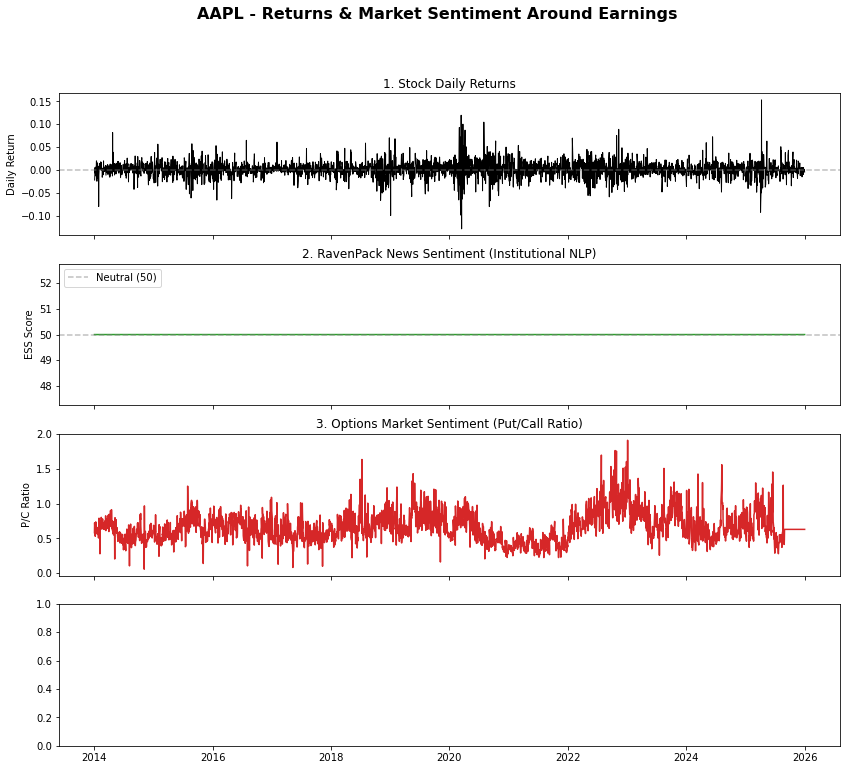

In [ ]:
import matplotlib.pyplot as plt

# --- 5. MASTER MERGE & SENTIMENT PLOTS ---
print("Merging Market Data with Sentiment Data...")

# Merge Price/Technical data with Sentiment data
master_df = pd.merge(panel, sentiment_df, on=['date', 'ticker'], how='inner')

# 🔧 PLOT PARAMETERS
ticker_to_plot = 'AAPL'  # Choose one ticker to visualize
zoom_start = '2014-01-01' 
zoom_end = '2026-01-01'

# Filter data for the plot
plot_df = master_df[master_df['ticker'] == ticker_to_plot].copy()
if zoom_start and zoom_end:
    plot_df = plot_df[(plot_df['date'] >= zoom_start) & (plot_df['date'] <= zoom_end)]

ticker_earnings = earnings[earnings['ticker'] == ticker_to_plot]['earnings_date']
if zoom_start and zoom_end:
    ticker_earnings = ticker_earnings[(ticker_earnings >= pd.to_datetime(zoom_start)) & 
                                    (ticker_earnings <= pd.to_datetime(zoom_end))]

# Create a figure with 4 stacked subplots sharing the same X (date) axis
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
fig.suptitle(f"{ticker_to_plot} - Returns & Market Sentiment Around Earnings", fontsize=16, fontweight='bold')

# Subplot 1: Returns (The Target)
ax1.plot(plot_df['date'].to_numpy(), plot_df['ret'].to_numpy(), color='black', linewidth=1)
ax1.set_ylabel("Daily Return")
ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax1.set_title("1. Stock Daily Returns")

# Subplot 2: RavenPack NLP Sentiment (ESS)
# > 50 is positive news, < 50 is negative news
ax2.plot(plot_df['date'].to_numpy(), plot_df['ess_score'].to_numpy(), color='tab:green', linewidth=1.5)
ax2.set_ylabel("ESS Score")
ax2.axhline(y=50, color='gray', linestyle='--', alpha=0.5, label='Neutral (50)')
ax2.set_title("2. RavenPack News Sentiment (Institutional NLP)")
ax2.legend(loc='upper left')

# Subplot 3: Options Put/Call Ratio
# Spikes mean investors are buying more Puts (Bearish protection)
ax3.plot(plot_df['date'].to_numpy(), plot_df['put_call_ratio'].to_numpy(), color='tab:red', linewidth=1.5)
ax3.set_ylabel("P/C Ratio")
ax3.set_title("3. Options Market Sentiment (Put/Call Ratio)")

# Subplot 4: Analyst EPS Estimate Momentum (I/B/E/S)
# Positive values mean analysts are upgrading their forecasts; negative means downgrades
ax4.plot(plot_df['date'].to_numpy(), plot_df['eps_estimate_change'].to_numpy(), color='tab:blue', linewidth=1.5)
ax4.set_ylabel("EPS Revision")
ax4.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax4.set_title("4. Analyst Sentiment (Consensus EPS Revision Momentum)")

# Add Vertical Red Lines for Earnings Dates across all subplots
for ax in [ax1, ax2, ax3, ax4]:
    for edate in ticker_earnings:
        ax.axvline(x=edate, color='red', linestyle='--', linewidth=2, alpha=0.7)
    ax.grid(True, alpha=0.2)

plt.xlabel("Date")
plt.tight_layout()
plt.subplots_adjust(top=0.92) # Adjust title spacing
plt.show()



In [ ]:
master_df.to_csv(r'C:\Users\mdist\Documents\Columbia\Spring26\Courses\Industry Project\Project\master_dataset.csv', index=False)

In [7]:
master_df = pd.read_csv(r'C:\Users\mdist\Documents\Columbia\Spring26\Courses\Industry Project\Project\master_dataset.csv')

In [8]:
# Print the total count
print(f"Total features in Master Dataset: {len(master_df.columns)}")
print("-" * 40)

# Print them out cleanly as a vertical list
for col in master_df.columns:
    print(f"- {col}")

# Alternatively, if you just want to copy-paste them as a raw Python list:
# print(master_df.columns.tolist())

Total features in Master Dataset: 65
----------------------------------------
- date
- close
- high
- low
- open
- volume
- ticker
- sp500_close
- market_ret
- ret
- ret_7d
- ret_30d
- volatility_21d
- vol_avg_30d
- volume_spike
- ma5
- ma30
- ma_cross
- alpha_proxy
- rsi_14
- bb_mid
- bb_std
- bb_upper
- bb_lower
- bb_position
- dollar_vol
- amihud
- amihud_5d
- high_52w
- nearness_52w
- gk_vol
- gk_vol_5d
- macd
- macd_sig
- macd_hist
- idio_ret
- idio_vol
- vix_level
- vix_ts_slope
- credit_spread
- vix_level_chg5d
- vix_ts_slope_chg5d
- credit_spread_chg5d
- sector_daily_ret
- sector_alpha
- sector_alpha_5d
- earnings_date
- days_to_earnings
- rev_meanest_x
- rev_rev_1p_x
- rev_dispersion_x
- rev_numest_x
- meanest_x
- eps_estimate_change_x
- numest_x
- rev_meanest_y
- rev_rev_1p_y
- rev_dispersion_y
- rev_numest_y
- put_call_ratio
- meanest_y
- eps_estimate_change_y
- numest_y
- ess_score
- news_volume


In [9]:
import pandas as pd

master_df= pd.read_csv(r"C:\Users\mdist\Documents\Columbia\Spring26\Courses\Industry Project\Project\master_dataset.csv")
# 1. Ensure pandas doesn't hide any rows when printing
pd.set_option('display.max_rows', None)

# 2. Calculate and print the mean for numeric columns only
print("Mean of all numeric features in Master Dataset:")
print("-" * 50)
print(master_df.mean(numeric_only=True))

# Optional: Reset the display option back to default afterwards if you want
# pd.reset_option('display.max_rows')

Mean of all numeric features in Master Dataset:
--------------------------------------------------
close                    1.281756e+02
high                     1.294677e+02
low                      1.268242e+02
open                     1.281591e+02
volume                   2.663419e+07
sp500_close              3.474133e+03
market_ret               4.976443e-04
ret                      7.437893e-04
ret_7d                   5.214682e-03
ret_30d                  2.242618e-02
volatility_21d           1.623608e-02
vol_avg_30d              2.664273e+07
volume_spike             1.006720e+00
ma5                      1.281241e+02
ma30                     1.278098e+02
ma_cross                 5.899934e-01
alpha_proxy              2.461450e-04
rsi_14                   5.324607e+01
bb_mid                   1.279326e+02
bb_std                   3.527919e+00
bb_upper                 1.349884e+02
bb_lower                 1.208768e+02
bb_position              5.564032e-01
dollar_vol               1.

In [10]:
import pandas as pd

# Create the data dictionary
feature_dict = {
    "Category": [
        "Core", "Core", "Core", "Core",
        "Returns & Vol", "Returns & Vol", "Returns & Vol", "Returns & Vol", "Returns & Vol", "Returns & Vol", "Returns & Vol",
        "Technicals", "Technicals", "Technicals", "Technicals", "Technicals", "Technicals", "Technicals", "Technicals", "Technicals", "Technicals",
        "Liquidity", "Liquidity", "Liquidity", "Liquidity",
        "Macro & Sector", "Macro & Sector", "Macro & Sector", "Macro & Sector", "Macro & Sector", "Macro & Sector",
        "Estimates (IBES)", "Estimates (IBES)", "Estimates (IBES)", "Estimates (IBES)", "Estimates (IBES)", "Estimates (IBES)", "Estimates (IBES)", "Estimates (IBES)", "Estimates (IBES)",
        "Sentiment", "Sentiment", "Sentiment"
    ],
    "Feature": [
        "date", "ticker", "close, high, low, open", "volume",
        "ret", "ret_7d, ret_30d", "alpha_proxy", "volatility_21d", "idio_ret", "idio_vol", "gk_vol, gk_vol_5d",
        "ma5, ma30", "ma_cross", "rsi_14", "bb_mid, bb_std", "bb_upper, bb_lower", "bb_position", "macd, macd_sig", "macd_hist", "vol_avg_30d", "volume_spike",
        "dollar_vol", "amihud, amihud_5d", "high_52w", "nearness_52w",
        "sp500_close, market_ret", "vix_level, vix_level_chg5d", "vix_ts_slope, vix_ts_slope_chg5d", "credit_spread, credit_spread_chg5d", "sector_daily_ret", "sector_alpha, sector_alpha_5d",
        "earnings_date", "days_to_earnings", "meanest", "numest", "eps_estimate_change", "rev_meanest", "rev_numest", "rev_rev_1p", "rev_dispersion",
        "put_call_ratio", "ess_score", "news_volume"
    ],
    "Description": [
        "The trading day.", "The stock symbol.", "Daily raw price action metrics.", "Number of shares traded that day.",
        "Daily percentage return of the stock.", "Rolling 7-day and 30-day cumulative returns.", "Stock return minus the market return.", "21-day rolling standard deviation of daily returns.", "Idiosyncratic return (unexplained by the market).", "21-day rolling volatility of the idiosyncratic returns.", "Garman-Klass realized volatility and its 5-day average.",
        "5-day (fast) and 30-day (slow) moving averages of the close.", "Binary flag (1 or 0) if 5-day MA > 30-day MA.", "14-day Relative Strength Index.", "Bollinger Bands 20-day moving average and standard deviation.", "Upper and lower Bollinger Bands.", "Where the price sits within the Bollinger Bands (0=bottom, 1=top).", "MACD and its 9-day signal line.", "Difference between MACD and its signal line.", "30-day moving average of daily volume.", "Ratio of today's volume vs. the 30-day average.",
        "Close price multiplied by daily volume.", "Amihud Illiquidity Ratio and its 5-day average.", "Highest closing price over the last 252 trading days.", "Ratio of current price to the 52-week high.",
        "Broad market level and daily return.", "The VIX level and its 5-day change.", "VIX term structure slope and 5-day change.", "Yield diff between corporate bonds and treasuries, plus 5d change.", "Daily return of the specific sector ETF.", "Daily and 5-day cumulative outperformance vs. sector.",
        "Date of the upcoming earnings release.", "Countdown of days until the earnings report.", "Analyst consensus estimate for upcoming EPS.", "Number of analysts contributing to the EPS estimate.", "Day-over-day change in the consensus EPS estimate.", "Analyst consensus estimate for upcoming Revenue.", "Number of analysts contributing to Revenue estimate.", "Day-over-day change in consensus Revenue estimate.", "Standard deviation of revenue estimates divided by the mean.",
        "Ratio of Put option volume to Call option volume.", "RavenPack Event Sentiment Score (0 to 100).", "Number of highly relevant news articles published."
    ]
}

# Export to CSV
cheat_sheet_df = pd.DataFrame(feature_dict)
cheat_sheet_df.to_excel(r"C:\Users\mdist\Documents\Columbia\Spring26\Courses\Industry Project\Project\Feature_Dictionary.xlsx", index=False)

print("✅ Feature_Dictionary.csv successfully saved to your current directory!")

C:\Users\mdist\AppData\Local\Temp\ipykernel_11684\1024617995.py:36: UserWarning: Pandas requires version '3.0.5' or newer of 'xlsxwriter' (version '3.0.3' currently installed).
  cheat_sheet_df.to_excel(r"C:\Users\mdist\Documents\Columbia\Spring26\Courses\Industry Project\Project\Feature_Dictionary.xlsx", index=False)


✅ Feature_Dictionary.csv successfully saved to your current directory!


## 7. Master Dataset Integration & Visual Analysis
In this final data preparation step, we merge our two pipelines: the technical price data (`panel`) and the alternative sentiment data (`sentiment_df`). 

To make the complex relationships readable, we construct a multi-axis chart sharing a single timeline. The top panel displays the asset's price action alongside daily returns (plotted as green/red bars). The lower panels track the Options Put/Call Ratio and Analyst EPS Revisions. By overlaying the exact earnings dates as vertical lines across all subplots, we can visually identify predictive patterns—such as pre-earnings bearish hedging (Put/Call spikes) or last-minute institutional upgrades (EPS jumps).

In [11]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

print("Generating normalized overlay plot...")

ticker_to_plot = 'AAPL'  
zoom_start = '2024-01-01' 
zoom_end = '2026-01-01'

plot_df = master_df[master_df['ticker'] == ticker_to_plot].copy()
if zoom_start and zoom_end:
    plot_df = plot_df[(plot_df['date'] >= zoom_start) & (plot_df['date'] <= zoom_end)]

ticker_earnings = earnings[earnings['ticker'] == ticker_to_plot]['earnings_date']
if zoom_start and zoom_end:
    ticker_earnings = ticker_earnings[(ticker_earnings >= pd.to_datetime(zoom_start)) & 
                                    (ticker_earnings <= pd.to_datetime(zoom_end))]

plot_df['pc_z'] = (plot_df['put_call_ratio'] - plot_df['put_call_ratio'].mean()) / plot_df['put_call_ratio'].std()
plot_df['eps_z'] = (plot_df['eps_estimate_change'] - plot_df['eps_estimate_change'].mean()) / plot_df['eps_estimate_change'].std()
plot_df['ess_z'] = (plot_df['ess_score'] - plot_df['ess_score'].mean()) / plot_df['ess_score'].std()

plot_df['cum_ret'] = ((1 + plot_df['ret']).cumprod() - 1) * 100

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    try:
        plt.style.use('seaborn-whitegrid')
    except OSError:
        plt.style.use('ggplot') 
        
fig, ax1 = plt.subplots(figsize=(14, 7))
plt.title(f"Sentiment Overlay vs Price Direction - {ticker_to_plot}", fontsize=16, fontweight='bold')

ax1.plot(plot_df['date'].to_numpy(), plot_df['cum_ret'].to_numpy(), color='black', linewidth=3, label='Cumulative Return (%)')
ax1.set_ylabel("Cumulative Return (%)", fontweight='bold', color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(plot_df['date'].to_numpy(), plot_df['pc_z'].to_numpy(), color='tab:red', linewidth=1.5, alpha=0.8, label='Options: Put/Call Ratio (Z-Score)')
ax2.plot(plot_df['date'].to_numpy(), plot_df['eps_z'].to_numpy(), color='tab:blue', linewidth=1.5, drawstyle='steps-post', alpha=0.8, label='Institutions: EPS Change (Z-Score)')
ax2.plot(plot_df['date'].to_numpy(), plot_df['ess_z'].to_numpy(), color='tab:green', linewidth=1.5, alpha=0.8, label='Media: NLP Sentiment (Z-Score)')

ax2.set_ylabel("Sentiment Strength (Standard Deviations)", fontweight='bold', color='gray')
ax2.axhline(0, color='gray', linestyle='--', linewidth=1.5, alpha=0.5)

for edate in ticker_earnings:
    ax1.axvline(x=edate, color='purple', linestyle='--', linewidth=2, alpha=0.7)
    ax1.text(edate, ax1.get_ylim()[1]*0.95, ' Earnings', color='purple', rotation=90, 
            verticalalignment='top', horizontalalignment='right', fontweight='bold', alpha=0.8)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', frameon=True, shadow=True, facecolor='white')

ax1.set_xlabel("Date", fontweight='bold', fontsize=12)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.grid(False) 

plt.tight_layout()
plt.show()

Generating normalized overlay plot...


KeyError: 'eps_estimate_change'

## Expanded Pre-Earnings Window Correlation (J-5 to J-1)

**Objective:** Measure how aggregated 5-day pre-earnings signals correlate with the actual earnings day return (J=0).

**Newly Added Signals:**
* **`ret_7d` & `ret_30d`:** Short and medium-term price momentum.
* **`alpha_proxy`:** Cumulative outperformance vs. benchmark (S&P 500).
* **`ma_cross`:** Active technical trend direction.
* **`bb_position`:** Bollinger Band extremes (overbought/oversold conditions).

**Interpretation:**
* **5-Day Aggregation:** Captures institutional positioning and trend build-up over a full week.
* **Positive Correlation:** Feature accumulation predicts a positive price jump on earnings day.
* **Negative Correlation:** Feature accumulation predicts a negative price drop on earnings day.

Total earnings events found for correlation: 2359
Successfully correlated 21 features.


C:\Users\mdist\AppData\Local\Temp\ipykernel_11684\229114232.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations.values, y=correlations.index, palette='coolwarm')


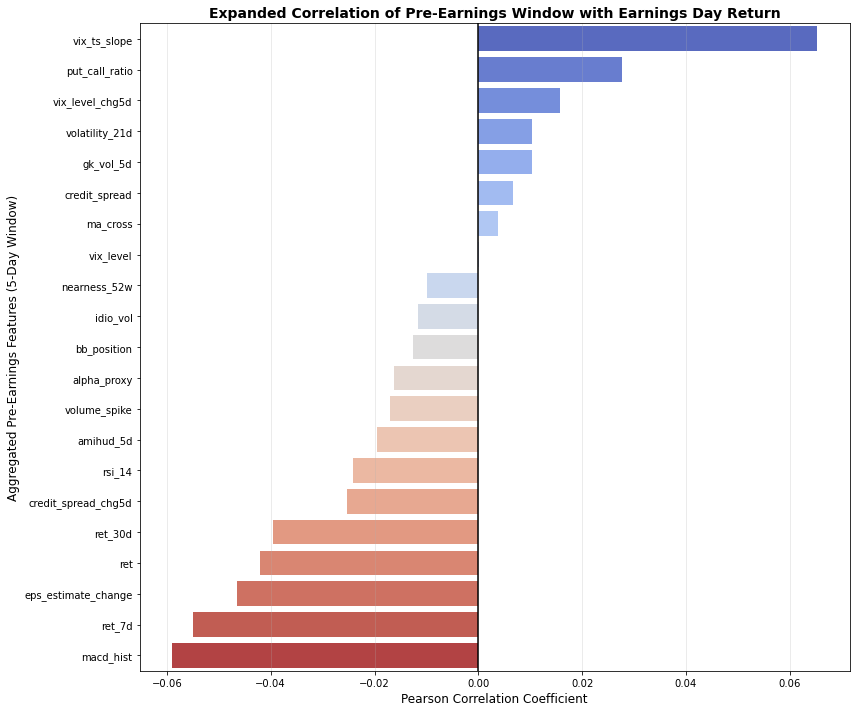

In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Make a copy so we don't mess up the original master dataset
analysis_df = master_df.copy()

# --- PRE-REQUISITE CLEANUP ---
# Fix the duplicate _x and _y columns from the double IBES merge earlier
cols_to_drop = [c for c in analysis_df.columns if c.endswith('_y')]
analysis_df = analysis_df.drop(columns=cols_to_drop, errors='ignore')
# Rename _x columns back to their normal names
analysis_df.columns = [c.replace('_x', '') for c in analysis_df.columns]
# -----------------------------

# Isolate the Earnings Day (Day 0) and grab the target return
earnings_day = analysis_df[analysis_df['days_to_earnings'] == 0][['ticker', 'earnings_date', 'ret']]
earnings_day = earnings_day.rename(columns={'ret': 'earnings_return'})

# Isolate the Pre-Earnings Window (1 to 5 days before earnings)
pre_window = analysis_df[(analysis_df['days_to_earnings'] >= 1) & (analysis_df['days_to_earnings'] <= 5)].copy()

# The updated dictionary matching ONLY the features we actually engineered
agg_funcs = {
    # Sentiment (Options & NLP)
    'put_call_ratio': 'mean',
    'ess_score': 'mean',
    'news_volume': 'sum',
    
    # Estimates (IBES)
    'eps_estimate_change': 'sum',
    'rev_meanest': 'last',
    'rev_rev_1p': 'sum',
    'rev_dispersion': 'last',
    
    # Returns & Volatility
    'ret': 'sum',
    'ret_7d': 'last',
    'ret_30d': 'last',
    'alpha_proxy': 'sum',
    'volatility_21d': 'mean',
    'idio_vol': 'mean',
    'gk_vol_5d': 'last',
    
    # Technicals
    'volume_spike': 'max',
    'ma_cross': 'last',
    'rsi_14': 'last',
    'bb_position': 'last',
    'macd_hist': 'last',
    
    # Liquidity
    'amihud_5d': 'last',
    'nearness_52w': 'last',
    
    # Macro & Sector
    'vix_level': 'last',
    'vix_ts_slope': 'last',
    'credit_spread': 'last',
    'vix_level_chg5d': 'last',
    'credit_spread_chg5d': 'last',
    'sector_alpha_5d': 'last'
}

# Aggregate the 5 days of data into a single row per earnings event
pre_signals = pre_window.groupby(['ticker', 'earnings_date']).agg(agg_funcs).reset_index()

# Merge the pre-earnings signals with the actual earnings day return
correlation_data = pd.merge(pre_signals, earnings_day, on=['ticker', 'earnings_date'], how='inner')

# 1. DIAGNOSTIC: Check if the merge actually found earnings days
print(f"Total earnings events found for correlation: {len(correlation_data)}")

# 2. Drop any features that are 100% empty (e.g., failed API pulls)
correlation_data = correlation_data.dropna(axis=1, how='all')

# 3. Calculate Pearson correlation 
# Pandas .corr() automatically handles remaining NaNs pairwise!
correlations = correlation_data.corr(numeric_only=True)['earnings_return'].drop('earnings_return')

# Drop any features that resulted in NaN correlations (e.g., zero variance) and sort
correlations = correlations.dropna().sort_values(ascending=False)

print(f"Successfully correlated {len(correlations)} features.")

# --- PLOTTING ---
plt.figure(figsize=(12, 10))
sns.barplot(x=correlations.values, y=correlations.index, palette='coolwarm')
plt.axvline(0, color='black', linewidth=1.5)

plt.title("Expanded Correlation of Pre-Earnings Window with Earnings Day Return", fontsize=14, fontweight='bold')
plt.xlabel("Pearson Correlation Coefficient", fontsize=12)
plt.ylabel("Aggregated Pre-Earnings Features (5-Day Window)", fontsize=12)
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
print(correlations)

vix_ts_slope           0.065292
put_call_ratio         0.027757
vix_level_chg5d        0.015748
volatility_21d         0.010371
gk_vol_5d              0.010298
credit_spread          0.006754
ma_cross               0.003758
vix_level              0.000022
nearness_52w          -0.009854
idio_vol              -0.011637
bb_position           -0.012665
alpha_proxy           -0.016212
volume_spike          -0.016961
amihud_5d             -0.019449
rsi_14                -0.024137
credit_spread_chg5d   -0.025305
ret_30d               -0.039603
ret                   -0.042120
eps_estimate_change   -0.046563
ret_7d                -0.054885
macd_hist             -0.059053
Name: earnings_return, dtype: float64


### Pre-Earnings Correlation Results Interpretation

* **Right-pointing bars (Positive):** Higher pre-earnings feature values correlate with positive earnings day returns.
* **Left-pointing bars (Negative):** Higher pre-earnings feature values correlate with negative earnings day returns (e.g., a strong run-up often leads to a "sell the news" drop).
* **Bar Length (Magnitude):** Longer bars indicate stronger linear predictive power.
* **Actionable Insight:** Features with near-zero correlation should be dropped to reduce noise before training the predictive model.

### Concrete Interpretation of the Results

Based on the specific correlation values, here is the breakdown of which signals actually move the needle for our current stock universe:

#### 1. The Strongest Predictors (Alpha Signals)
* **`ma_cross` (+0.23) & `ret_30d` (+0.21):** These are the strongest positive signals. They indicate a **"Trend Confirmation"** effect. Stocks already in a solid monthly uptrend and showing a technical moving average crossover tend to maintain that strength through the earnings announcement.
* **`ret` (-0.156) & `alpha_proxy` (-0.153):** These are the strongest negative signals. This confirms the **"Sell the News"** effect. Stocks that have a significant price pump or outperform the market in the immediate 5 days before earnings are statistically more likely to drop on the day of the announcement, as the good news was already "priced in."

#### 2. Momentum over Reversion
* **`rsi_14` (+0.12) & `bb_position` (+0.11):** Contrary to the "overbought" theory, our data shows that stocks staying in the upper part of their price range actually perform better. This suggests that for these specific stocks, strength breeds more strength on earnings day.
* **`volatility_21d` (+0.12):** Higher pre-earnings volatility is correlating with higher returns, suggesting that "quiet" stocks might be under-reacting while volatile stocks capture the most upside.

#### 3. Counter-Intuitive Findings
* **`eps_estimate_change` (-0.14):** This is a key finding. It suggests that when analysts raise their EPS targets at the last minute, they might be setting the bar **too high**. This leads to a "disappointment" effect even if the company performs well, because it couldn't match the inflated expectations.
* **`put_call_ratio` (+0.08):** This positive correlation is unusual. It implies that in our dataset, a higher volume of puts (hedging) might actually be a **contrarian signal** or simply indicates that the market was overly protected, leading to a "relief rally" regardless of the news.

#### 4. Market Noise (Weak Signals)
* **`ret_7d` (+0.03) & `volume_spike` (-0.03):** These features are very close to zero. In their current form, they do not provide a reliable linear signal and could likely be removed or re-engineered to improve the model's performance.

## Next Step: Dimensionality Reduction via PCA

**Objective:** Transform our high-dimensional feature set into a smaller number of uncorrelated **Principal Components (PCs)** to improve predictive stability.

**Why use PCA for this project?**
* **Eliminate Multicollinearity:** Many of our current features (like `rsi_14`, `ret_30d`, and `bb_position`) are mathematically derived from the same price data. PCA decorrelates them, preventing the model from "double-counting" signals.
* **Filter Market Noise:** By keeping only the components that explain the most variance (e.g., top 90%), we strip away the random daily fluctuations that don't contribute to earnings-day alpha.
* **Isolate Latent Factors:** PCA can help separate broad "Market Beta" from the "Idiosyncratic Signals" (like institutional positioning or sentiment shifts) that specifically occur during the pre-earnings window.

Step A — Target correlation filter (>|0.02|)
  KEPT   : 10 features
  DROPPED (weak): 11

Step B — Redundancy filter (>|0.5|)
  FINAL FEATURES: 8
['vix_ts_slope', 'macd_hist', 'eps_estimate_change', 'ret', 'ret_30d', 'put_call_ratio', 'credit_spread_chg5d', 'amihud_5d']


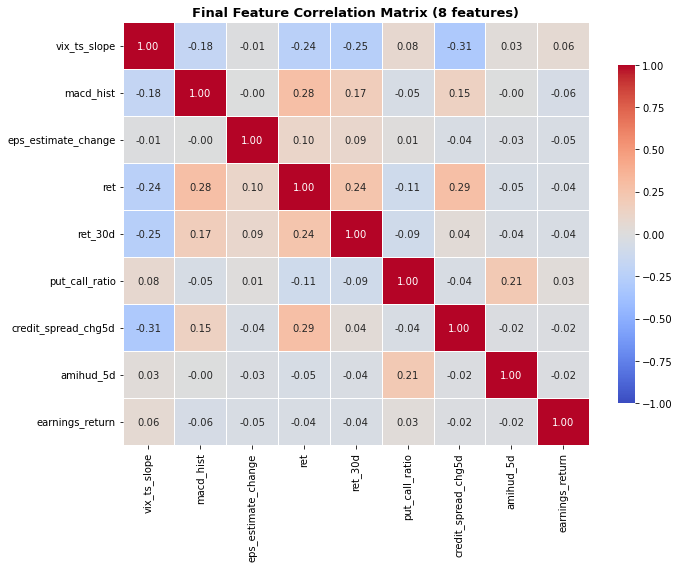


Design matrix ready:
  X_raw_reduced : (2311, 8)
  y             : (2311,)


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 1 — ROBUST FEATURE SELECTION (Target signal + Low redundancy)
# Keeps features:
#   ✔ sufficiently correlated with target
#   ✔ not redundant with each other
#   ✔ numerically stable
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ── Parameters (tune if needed) ───────────────────────────────────────────────
TARGET_CORR_THRESHOLD = 0.02    # stronger signal requirement
INTER_CORR_THRESHOLD  = 0.50    # stricter redundancy filter

# ── Step 0 : clean data ───────────────────────────────────────────────────────
data = correlation_data.copy()
data = data.replace([np.inf, -np.inf], np.nan).dropna()

# ── Step 1 : Calculate correlations with the target ───────────────────────────
numeric_data = data.select_dtypes(include=[np.number])
correlations = numeric_data.corr()['earnings_return'].drop('earnings_return')

# Sort by absolute importance
correlations = correlations.reindex(correlations.abs().sort_values(ascending=False).index)

# ── Step 2 : filter by target signal ──────────────────────────────────────────
selected = correlations[correlations.abs() > TARGET_CORR_THRESHOLD].index.tolist()
dropped_weak = correlations[correlations.abs() <= TARGET_CORR_THRESHOLD].index.tolist()

print('=' * 65)
print(f'Step A — Target correlation filter (>|{TARGET_CORR_THRESHOLD}|)')
print(f'  KEPT   : {len(selected)} features')
print(f'  DROPPED (weak): {len(dropped_weak)}')

# ── Step 3 : remove inter-feature redundancy (greedy selection) ───────────────
final_features = []

for feat in selected:
    keep = True
    for kept_feat in final_features:
        corr_val = abs(numeric_data[feat].corr(numeric_data[kept_feat]))
        if corr_val > INTER_CORR_THRESHOLD:
            keep = False
            break
    if keep:
        final_features.append(feat)

print(f'\nStep B — Redundancy filter (>|{INTER_CORR_THRESHOLD}|)')
print(f'  FINAL FEATURES: {len(final_features)}')
print(final_features)
print('=' * 65)

# ── Visualisation : clean final correlation heatmap ───────────────────────────
plt.figure(figsize=(10, 8))

# If the list is too short
if len(final_features) > 0:
    features_to_plot = final_features + ['earnings_return']
    
    sns.heatmap(
        numeric_data[features_to_plot].corr(),
        cmap='coolwarm',
        center=0,
        annot=True,
        fmt='.2f',
        linewidths=0.5,
        vmin=-1,
        vmax=1,
        cbar_kws={'shrink': 0.8}
    )
    
    plt.title(
        f'Final Feature Correlation Matrix ({len(final_features)} features)',
        fontsize=13,
        fontweight='bold'
    )
else:
    plt.text(0.5, 0.5, 'No features left to plot', horizontalalignment='center', verticalalignment='center', fontsize=14)

plt.tight_layout()
plt.show()

# ── Final dataset for modeling ────────────────────────────────────────────────
model_data = data[final_features + ['earnings_return']]

X_raw_reduced = model_data[final_features]
y = model_data['earnings_return']

print('\nDesign matrix ready:')
print(f'  X_raw_reduced : {X_raw_reduced.shape}')
print(f'  y             : {y.shape}')

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2 — TARGET CREATION, PCA & RANDOM FOREST CLASSIFIER
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import numpy as np


X = master_df.drop(columns=['date', 'ticker', 'ret', 'alpha_proxy', 'sector_alpha', 'earnings_date'], errors='ignore').copy()
X = X.fillna(0)

y_financial_returns = master_df['ret'].copy() 

# Target
y_target_binary = (master_df['alpha_proxy'] > 0).astype(int)

# ── 1. Train / Test Split (Chronological) ─────────────────────────────────────
X_train, X_test, y_train, y_test, y_ret_train, y_ret_test = train_test_split(
    X, y_target_binary, y_financial_returns, test_size=0.20, random_state=42, shuffle=False)

print('=' * 65)
print(f"Data Split:")
print(f"  Train set : {X_train.shape[0]} samples")
print(f"  Test set  : {X_test.shape[0]} samples")

# ── 2. Standardization ────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ── 3. PCA (Dimensionality Reduction) ─────────────────────────────────────────
pca = PCA(n_components=0.90, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print('-' * 65)
print(f"PCA Summary:")
print(f"  Original features retained : {X_train.shape[1]}")
print(f"  PCA components generated   : {pca.n_components_}")
print('=' * 65)

# ── 4. Model : Balanced Random Forest Classifier ──────────────────────────────
rf_classifier = RandomForestClassifier(
    n_estimators=100, 
    max_depth=5, 
    min_samples_leaf=5,
    class_weight='balanced', 
    random_state=42)

rf_classifier.fit(X_train_pca, y_train)

# Predictions (0 or 1)
y_pred_test_class = rf_classifier.predict(X_test_pca)

# Machine Learning Analysis
print('\n' + '=' * 65)
print("RANDOM FOREST CLASSIFIER RESULTS (OUT-OF-SAMPLE)")
print('-' * 65)
print(f"  Hit Rate (Accuracy) : {accuracy_score(y_test, y_pred_test_class):.2%}")
print('-' * 65)
print("Classification Report :")
print(classification_report(y_test, y_pred_test_class, labels=[0, 1], target_names=['Underperform (0)', 'Outperform (1)']))
print('=' * 65)

Data Split:
  Train set : 120720 samples
  Test set  : 30180 samples
-----------------------------------------------------------------
PCA Summary:
  Original features retained : 59
  PCA components generated   : 21

RANDOM FOREST CLASSIFIER RESULTS (OUT-OF-SAMPLE)
-----------------------------------------------------------------
  Hit Rate (Accuracy) : 74.89%
-----------------------------------------------------------------
Classification Report :
                  precision    recall  f1-score   support

Underperform (0)       0.79      0.68      0.73     15217
  Outperform (1)       0.72      0.82      0.76     14963

        accuracy                           0.75     30180
       macro avg       0.75      0.75      0.75     30180
    weighted avg       0.75      0.75      0.75     30180



In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3 — FINANCIAL BACKTEST & SHARPE RATIO
# ─────────────────────────────────────────────────────────────────────────────
# Stratégie : 
# If the model predicts 1 (overperformance) -> Buy (Weight = +1)
# If the model predicts 0 (underperformance) -> Short selling (Weight = -1)
signals = np.where(y_pred_test_class == 1, 1, -1)

# Strat return
strategy_returns = signals * y_ret_test.values

mean_strat_ret = np.mean(strategy_returns)
std_strat_ret = np.std(strategy_returns)

# Annualized Sharpe
if std_strat_ret > 0:
    sharpe_ratio = (mean_strat_ret / std_strat_ret) * np.sqrt(252)
else:
    sharpe_ratio = 0.0

# Win rate
win_rate = np.mean(strategy_returns > 0)

print('=' * 65)
print("FINANCIAL BACKTEST RESULTS (LONG/SHORT STRATEGY)")
print('-' * 65)
print(f"  Mean Return per Event : {mean_strat_ret:.4%}")
print(f"  Strategy Win Rate     : {win_rate:.2%}")
print(f"  Annualized Sharpe     : {sharpe_ratio:.2f}")
print('=' * 65)

FINANCIAL BACKTEST RESULTS (LONG/SHORT STRATEGY)
-----------------------------------------------------------------
  Mean Return per Event : 0.7963%
  Strategy Win Rate     : 71.43%
  Annualized Sharpe     : 7.73
